In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
X = np.array([
    [1,7],#A
    [2,8],#B
    [3,7],#C
    [4,6],#D
    [5,5] #E
])

y_labels = np.array(['F','F','P','P','P'])

le = LabelEncoder()
y = le.fit_transform(y_labels)

In [3]:
k=3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X,y)

KNeighborsClassifier(n_neighbors=3)

In [4]:
new_student = np.array([[3.5,6.5]])
prediction = knn.predict(new_student)
print("Prediction",le.inverse_transform(prediction)[0])

Prediction P


In [5]:
# Create Grid
X_min, X_max = X[:,0].min()-1,X[:,0].max()+1
y_min, y_max = X[:,1].min()-1,X[:,1].max()+1
xx,yy = np.meshgrid(np.arange(X_min,X_max,0.1),np.arange(y_min,y_max,0.1))


In [6]:
# Predict For Values For each point in the grid
Z = knn.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)


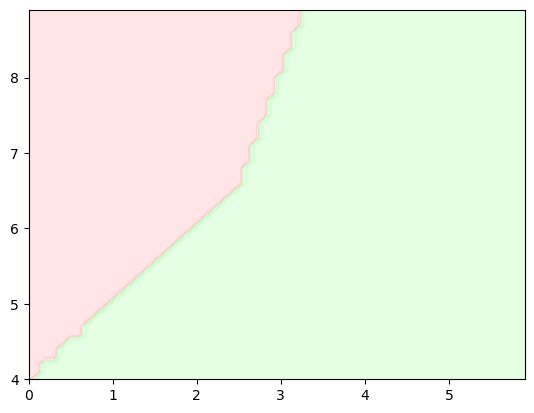

In [13]:
cmap_light = ListedColormap(['#FFAAAA','#AAFFAA'])
cmap_bold = {0:'red',1:'green'}
plt.contourf(xx, yy, Z, alpha=0.3,cmap=cmap_light)

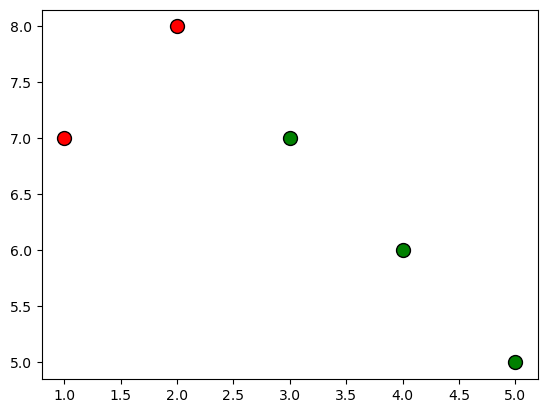

In [14]:
for class_value in np.unique(y):
    plt.scatter(X[y==class_value,0],X[y==class_value,1],
                c = cmap_bold[class_value],
                label = le.inverse_transform([class_value])[0],edgecolor='k',s=100)

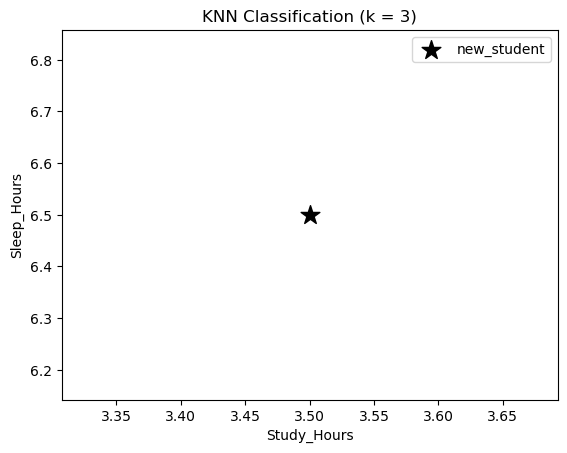

In [15]:
plt.scatter(new_student[0,0],new_student[0,1], c = 'black', marker = '*', s = 200, label='new_student')
plt.xlabel("Study_Hours")
plt.ylabel("Sleep_Hours")
plt.title(f"KNN Classification (k = {k})")
plt.legend()
plt.show()

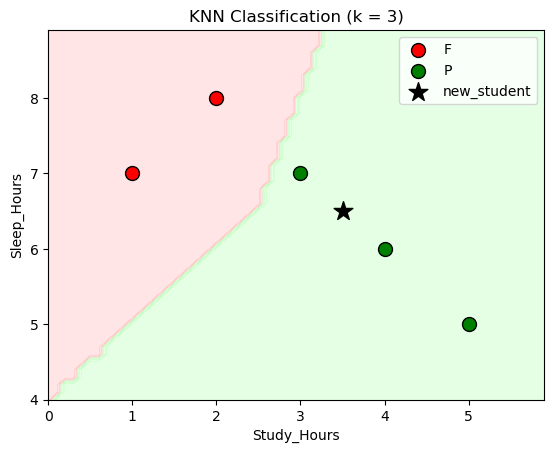

In [16]:
cmap_light = ListedColormap(['#FFAAAA','#AAFFAA'])
cmap_bold = {0:'red',1:'green'}
plt.contourf(xx, yy, Z, alpha=0.3,cmap=cmap_light)

for class_value in np.unique(y):
    plt.scatter(X[y==class_value,0],X[y==class_value,1],
                c = cmap_bold[class_value],
                label = le.inverse_transform([class_value])[0],edgecolor='k',s=100)
plt.scatter(new_student[0,0],new_student[0,1], c = 'black', marker = '*', s = 200, label='new_student')
plt.xlabel("Study_Hours")
plt.ylabel("Sleep_Hours")
plt.title(f"KNN Classification (k = {k})")
plt.legend()
plt.show()